# Patchscope Activation Interpretation Analysis

Analyze results from the Patchscope activation patching experiment: does injecting a persona's hidden-state activation into an interpretation pass reveal privileged information about that persona's internal reasoning?

**Sections:** Setup → Load Data → Overview → Answer Extraction Accuracy → Persona Probe → Self-Recognition → Agreement Probe → Layer Analysis → Condition Comparison → Qualitative Examples → Key Findings

**References:**
- Patchscopes: Ghandeharioun et al., arXiv:2401.06102
- SelfIE: Chen et al., arXiv:2403.10949

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
sns.set_style("whitegrid")

# ── Set your results file path here ─────────────────────────────────
# RESULTS_PATH = "results/raw/patchscope_tinyllama-1-1b--v1-0_20260320_194928_matrix.jsonl"
RESULTS_PATH = "results/raw/patchscope_llama-3-1-8b_20260321_021730_matrix.jsonl"

# Extract model name from results path
def _extract_model_name(path: str) -> str:
    """Extract model name from patchscope results filename."""
    filename = Path(path).stem
    if filename.startswith("patchscope_"):
        parts = filename.split("_")
        if len(parts) >= 3:
            model_parts = parts[1:-2]
            model_name = "_".join(model_parts)
            model_name = model_name.replace("-", " ").replace("_", " ")
            if "tinyllama" in model_name.lower():
                return "TinyLlama 1.1B"
            elif "llama 3 1 8b" in model_name.lower():
                return "Llama 3.1 8B"
            elif "llama 3 3" in model_name.lower():
                return "Llama 3.3 70B"
            else:
                return model_name.title()
    return "Unknown Model"

MODEL = _extract_model_name(RESULTS_PATH)

# Resolve path
_p = Path(RESULTS_PATH)
if not _p.is_absolute():
    for base in [Path.cwd(), Path.cwd().parent]:
        candidate = base / RESULTS_PATH
        if candidate.exists():
            RESULTS_PATH = str(candidate)
            break
if not Path(RESULTS_PATH).exists():
    raise FileNotFoundError(f"Results file not found: {RESULTS_PATH}")


# Model footer on every figure — idempotent (safe to re-run)
def _add_model_footer(fig, *, y=-0.04):
    fig.text(0.5, y, MODEL, ha="center", va="top", fontsize=9, color="dimgray")

if not hasattr(plt, "_original_subplots"):
    plt._original_subplots = plt.subplots

def _subplots_with_model(*args, **kwargs):
    fig, axes = plt._original_subplots(*args, **kwargs)
    _add_model_footer(fig)
    return fig, axes

plt.subplots = _subplots_with_model

## 2. Load Data

In [2]:
records = []
with open(RESULTS_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue

df = pd.DataFrame(records)

# Drop error rows
n_errors = df["error"].notna().sum() if "error" in df.columns else 0
if n_errors > 0:
    print(f"Dropping {n_errors} error rows.")
    df = df[df["error"].isna()].copy()

print(f"Loaded {len(df)} records from {Path(RESULTS_PATH).name}")
print(f"Questions: {sorted(df['question_id'].unique())}")
print(f"Source personas: {sorted(df['source_persona'].unique())}")
print(f"Evaluator personas: {sorted(df['evaluator_persona'].unique())}")
print(f"Templates: {sorted(df['template_name'].unique())}")
print(f"Conditions: {sorted(df['condition'].unique())}")
print(f"Source layers: {sorted(df['source_layer'].unique())}")
print(f"Parse success rate: {df['parse_success'].mean():.1%}")
df.head(2)

Loaded 1400 records from patchscope_llama-3-1-8b_20260321_021730_matrix.jsonl
Questions: ['pol_002', 'pol_032', 'pol_062', 'pol_083', 'pol_084', 'pol_186', 'pol_193']
Source personas: ['persona_conservative']
Evaluator personas: ['neutral_evaluator', 'persona_conservative', 'persona_progressive']
Templates: ['agreement_probe', 'answer_extraction', 'open_summary', 'persona_probe', 'self_recognition']
Conditions: ['real', 'shuffled', 'text_only_baseline']
Source layers: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Parse success rate: 78.9%


,experiment,template_name,model,question_id,source_persona,evaluator_persona,condition,source_layer,injection_layer,injection_mode,...,choice_probs,choice_logits,predicted,is_correct,relevancy_scores,mean_relevancy,source_direct_answer,source_answer_probs,error,timestamp
0,patchscope,answer_extraction,meta-llama/Llama-3.1-8B-Instruct,pol_186,persona_conservative,persona_conservative,real,10,8,replace,...,"{'A': 0.009329866617918015, 'B': 0.93691796064...","{'A': 19.921875, 'B': 24.53125, 'C': 21.15625,...",B,True,None,None,B,"{'A': 0.005042622331529856, 'B': 0.94605553150...",None,2026-03-21T02:17:46.309355+00:00
1,patchscope,answer_extraction,meta-llama/Llama-3.1-8B-Instruct,pol_186,persona_conservative,persona_conservative,text_only_baseline,10,8,replace,...,"{'A': 0.009329866617918015, 'B': 0.93691796064...","{'A': 19.921875, 'B': 24.53125, 'C': 21.15625,...",B,True,None,None,B,"{'A': 0.005042622331529856, 'B': 0.94605553150...",None,2026-03-21T02:17:46.358517+00:00


## 3. Overview

Counts per condition, template, and evaluator. Parse success rates.

In [3]:
# Records per condition
print("Records per condition:")
display(df["condition"].value_counts().to_frame("count"))

# Parse success by template
parse_by_tmpl = df.groupby("template_name")["parse_success"].agg(["sum", "count", "mean"]).round(3)
parse_by_tmpl.columns = ["parsed", "total", "parse_rate"]
print("\nParse success by template:")
display(parse_by_tmpl)

# Cross-tab: template x condition
print("\nRecords per template x condition:")
display(pd.crosstab(df["template_name"], df["condition"]))

Records per condition:


,count
condition,
real,913
text_only_baseline,247
shuffled,240



Parse success by template:


,parsed,total,parse_rate
template_name,,,
agreement_probe,276,276,1.0
answer_extraction,278,278,1.0
open_summary,0,295,0.0
persona_probe,274,274,1.0
self_recognition,277,277,1.0



Records per template x condition:


condition,real,shuffled,text_only_baseline
template_name,,,
agreement_probe,183,43,50
answer_extraction,183,48,47
open_summary,182,59,54
persona_probe,183,42,49
self_recognition,182,48,47


## 4. Answer Extraction Accuracy

Can the model recover the source persona's answer from the injected activation?

- **real**: activation patched from source → should be above chance if activations carry answer info
- **text_only_baseline**: no activation → measures evaluator persona bias
- **shuffled**: wrong question's activation → should be near chance

Answer extraction accuracy by condition:


,accuracy,correct,total
condition,,,
real,0.503,92,183
shuffled,0.500,24,48
text_only_baseline,0.532,25,47



Accuracy by condition x evaluator:


accuracy   n
condition          evaluator_persona                 
real               neutral_evaluator        0.344  61
                   persona_conservative     0.984  61
                   persona_progressive      0.180  61
shuffled           neutral_evaluator        0.353  17
                   persona_conservative     1.000  14
                   persona_progressive      0.235  17
text_only_baseline neutral_evaluator        0.500  16
                   persona_conservative     1.000  14
                   persona_progressive      0.176  17


Accuracy pivot (condition x evaluator):


evaluator_persona,neutral_evaluator,persona_conservative,persona_progressive
condition,,,
real,0.344,0.984,0.180
shuffled,0.353,1.000,0.235
text_only_baseline,0.500,1.000,0.176


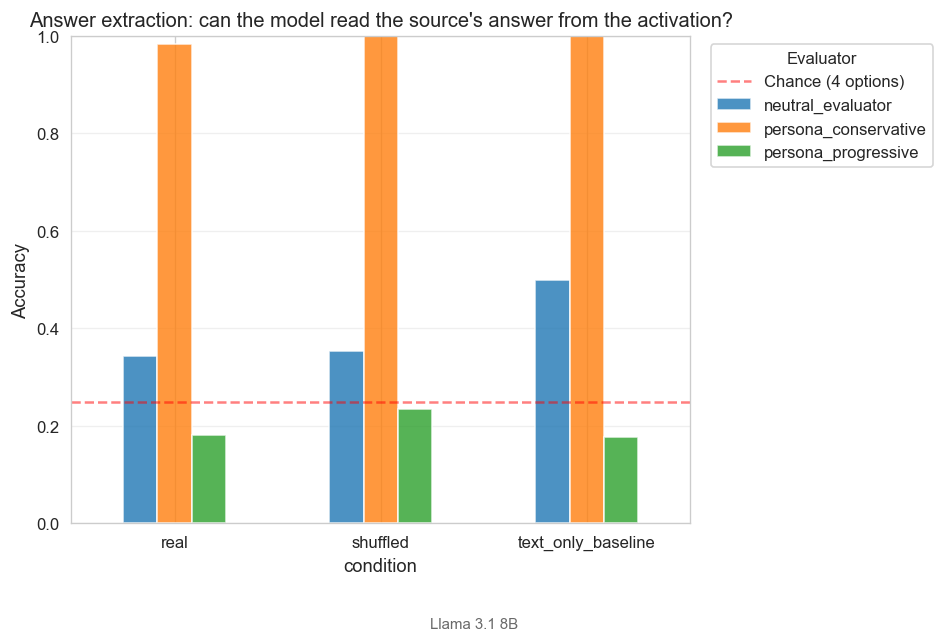

In [4]:
ae = df[df["template_name"] == "answer_extraction"].copy()
ae = ae[ae["source_direct_answer"].notna()].copy()

# Match: parsed first letter == source direct answer
ae["correct"] = ae.apply(
    lambda r: (r["parsed_answer"] or "")[:1] == r["source_direct_answer"]
    if r["parse_success"] else False,
    axis=1,
)

# Accuracy by condition
acc_by_cond = ae.groupby("condition")["correct"].agg(["mean", "sum", "count"])
acc_by_cond.columns = ["accuracy", "correct", "total"]
print("Answer extraction accuracy by condition:")
display(acc_by_cond.round(3))

# Accuracy by condition x evaluator persona
acc_cond_eval = ae.groupby(["condition", "evaluator_persona"])["correct"].agg(["mean", "count"])
acc_cond_eval.columns = ["accuracy", "n"]
print("\nAccuracy by condition x evaluator:")
display(acc_cond_eval.round(3))

# Pivot table (text-friendly version of the chart)
pivot = ae.groupby(["condition", "evaluator_persona"])["correct"].mean().unstack()
print("\nAccuracy pivot (condition x evaluator):")
display(pivot.round(3))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax, alpha=0.8, edgecolor="white")
ax.axhline(0.25, color="red", linestyle="--", alpha=0.5, label="Chance (4 options)")
ax.set_ylabel("Accuracy")
ax.set_title("Answer extraction: can the model read the source's answer from the activation?")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Evaluator", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 5. Persona Probe

Can the model identify which persona (Conservative / Progressive) produced the activation?

Persona probe accuracy by condition:


,accuracy,correct,total
condition,,,
real,0.667,122,183
shuffled,0.571,24,42
text_only_baseline,0.673,33,49



Confusion matrix (real condition):


parsed_lower,conservative,progressive,All
expected,,,
conservative,122,61,183
All,122,61,183



Accuracy pivot (condition x evaluator):


evaluator_persona,neutral_evaluator,persona_conservative,persona_progressive
condition,,,
real,1.0,1.0,0.0
shuffled,1.0,1.0,0.0
text_only_baseline,1.0,1.0,0.0


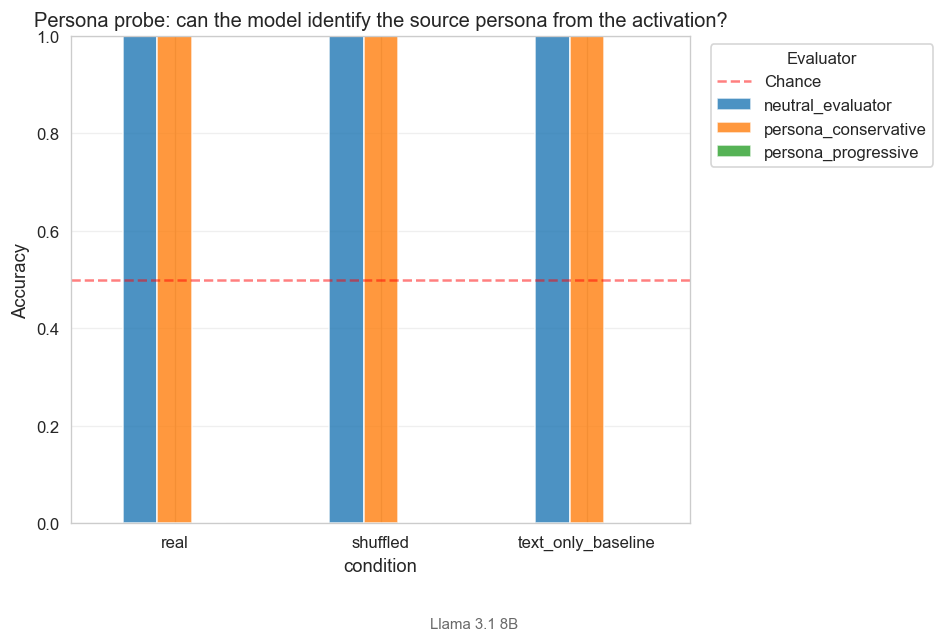

In [5]:
pp = df[df["template_name"] == "persona_probe"].copy()
pp = pp[pp["parse_success"]].copy()

# Ground truth: source persona -> expected label (case-insensitive)
def expected_persona_label(source_persona):
    if "conservative" in source_persona.lower():
        return "conservative"
    elif "progressive" in source_persona.lower():
        return "progressive"
    return None

pp["expected"] = pp["source_persona"].map(expected_persona_label)
pp["parsed_lower"] = pp["parsed_answer"].str.lower()
pp = pp[pp["expected"].notna()].copy()
pp["correct"] = pp["parsed_lower"] == pp["expected"]

# Accuracy by condition
acc = pp.groupby("condition")["correct"].agg(["mean", "sum", "count"])
acc.columns = ["accuracy", "correct", "total"]
print("Persona probe accuracy by condition:")
display(acc.round(3))

# Confusion matrix for real condition
real_pp = pp[pp["condition"] == "real"]
if not real_pp.empty:
    print("\nConfusion matrix (real condition):")
    ct = pd.crosstab(real_pp["expected"], real_pp["parsed_lower"], margins=True)
    display(ct)

# Pivot table (text-friendly version of the chart)
pivot = pp.groupby(["condition", "evaluator_persona"])["correct"].mean().unstack()
print("\nAccuracy pivot (condition x evaluator):")
display(pivot.round(3))

# By condition x evaluator
fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax, alpha=0.8, edgecolor="white")
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Chance")
ax.set_ylabel("Accuracy")
ax.set_title("Persona probe: can the model identify the source persona from the activation?")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Evaluator", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 6. Self-Recognition

When the evaluator and source are the *same* persona, does it answer "Self"? When different, "Other"?

Self-recognition accuracy by condition:


,accuracy,n
condition,,
real,0.330,182
shuffled,0.333,48
text_only_baseline,0.255,47



--- real ---


,accuracy,n
is_self_pair,,
Cross pair,0.496,121
Self pair,0.000,61



--- text_only_baseline ---


,accuracy,n
is_self_pair,,
Cross pair,0.387,31
Self pair,0.000,16



--- shuffled ---


,accuracy,n
is_self_pair,,
Cross pair,0.444,36
Self pair,0.000,12



P("Self") by evaluator x source (real condition):


source_persona,persona_conservative
evaluator_persona,
neutral_evaluator,0.0
persona_conservative,0.0
persona_progressive,1.0


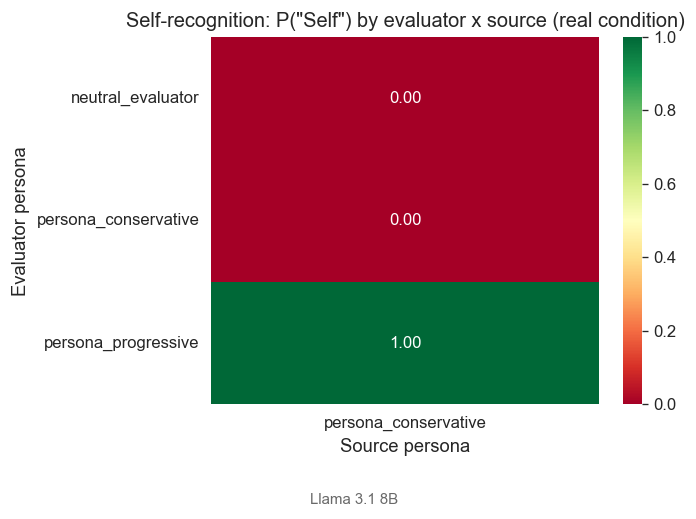

In [6]:
sr = df[df["template_name"] == "self_recognition"].copy()
sr = sr[sr["parse_success"]].copy()

sr["is_self_pair"] = sr["source_persona"] == sr["evaluator_persona"]
sr["expected"] = sr["is_self_pair"].map({True: "self", False: "other"})
sr["parsed_lower"] = sr["parsed_answer"].str.lower()
sr["correct"] = sr["parsed_lower"] == sr["expected"]

# Overall accuracy
acc = sr.groupby("condition")["correct"].agg(["mean", "count"])
acc.columns = ["accuracy", "n"]
print("Self-recognition accuracy by condition:")
display(acc.round(3))

# Breakdown: self-pairs vs cross-pairs
for cond in ["real", "text_only_baseline", "shuffled"]:
    sub = sr[sr["condition"] == cond]
    if sub.empty:
        continue
    print(f"\n--- {cond} ---")
    breakdown = sub.groupby("is_self_pair")["correct"].agg(["mean", "count"])
    breakdown.columns = ["accuracy", "n"]
    breakdown.index = breakdown.index.map({True: "Self pair", False: "Cross pair"})
    display(breakdown.round(3))

# Heatmap: evaluator x source, average "Self" response rate (real condition)
real_sr = sr[sr["condition"] == "real"].copy()
if not real_sr.empty:
    real_sr["said_self"] = (real_sr["parsed_lower"] == "self").astype(float)
    pivot = real_sr.pivot_table(
        values="said_self", index="evaluator_persona", columns="source_persona", aggfunc="mean"
    )
    print('\nP("Self") by evaluator x source (real condition):')
    display(pivot.round(2))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
    ax.set_title('Self-recognition: P("Self") by evaluator x source (real condition)')
    ax.set_ylabel("Evaluator persona")
    ax.set_xlabel("Source persona")
    plt.tight_layout()
    plt.show()

## 7. Agreement Probe

Does the activation correspond to agreeing or disagreeing with the statement?

Agreement probe responses (parsed_answer counts):


,parsed_lower,disagree
condition,source_persona,
real,persona_conservative,183
shuffled,persona_conservative,43
text_only_baseline,persona_conservative,50



Agree/Disagree rates by condition x source persona:


,condition,source_persona,agree_rate,disagree_rate,n
0,real,persona_conservative,0.0,1.0,183
1,text_only_baseline,persona_conservative,0.0,1.0,50
2,shuffled,persona_conservative,0.0,1.0,43


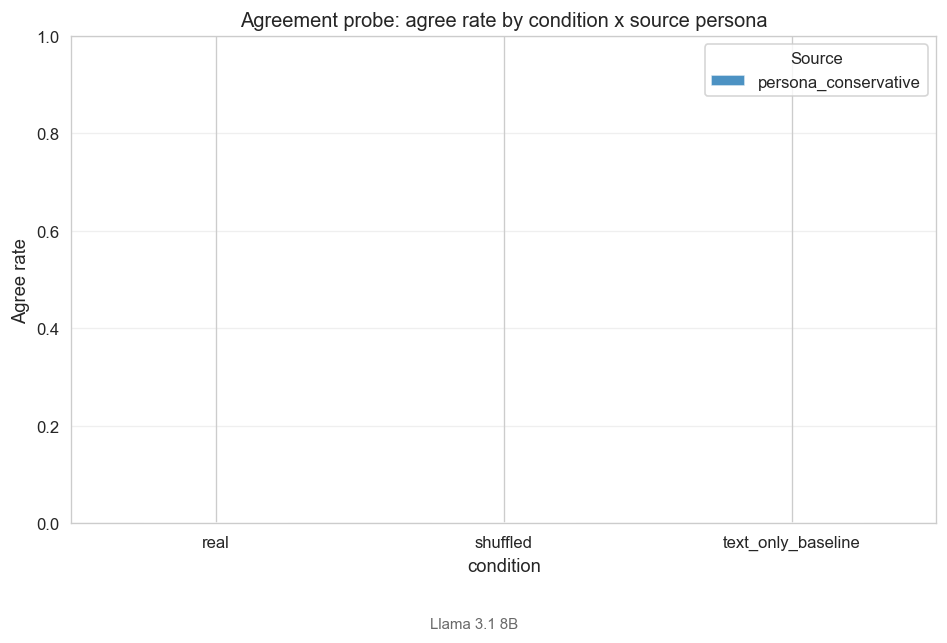

In [7]:
ap = df[df["template_name"] == "agreement_probe"].copy()
ap = ap[ap["parse_success"]].copy()
ap["parsed_lower"] = ap["parsed_answer"].str.lower()

# Response distribution by condition x source persona
print("Agreement probe responses (parsed_answer counts):")
ct = pd.crosstab([ap["condition"], ap["source_persona"]], ap["parsed_lower"])
display(ct)

# Do conservative and progressive sources diverge?
agree_rows = []
for cond in ["real", "text_only_baseline", "shuffled"]:
    sub = ap[ap["condition"] == cond]
    if sub.empty:
        continue
    for sp in sorted(sub["source_persona"].unique()):
        sp_sub = sub[sub["source_persona"] == sp]
        agree_rows.append({
            "condition": cond,
            "source_persona": sp,
            "agree_rate": (sp_sub["parsed_lower"] == "agree").mean(),
            "disagree_rate": (sp_sub["parsed_lower"] == "disagree").mean(),
            "n": len(sp_sub),
        })

agree_df = pd.DataFrame(agree_rows)
print("\nAgree/Disagree rates by condition x source persona:")
display(agree_df.round(3))

# Bar chart
if not agree_df.empty and (agree_df["agree_rate"].sum() > 0 or agree_df["disagree_rate"].sum() > 0):
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot = agree_df.pivot(index="condition", columns="source_persona", values="agree_rate").fillna(0)
    pivot.plot(kind="bar", ax=ax, alpha=0.8, edgecolor="white")
    ax.set_ylabel("Agree rate")
    ax.set_title("Agreement probe: agree rate by condition x source persona")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Source")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("\n(No Agree/Disagree responses parsed — check parsed_answer values above.)")

## 8. Layer Analysis

How does accuracy change across extraction layers? Do deeper layers carry more information?

Answer extraction accuracy by layer (real condition):


,accuracy,n
source_layer,,
10,0.524,21
11,0.500,18
12,0.500,18
13,0.500,18
14,0.500,18
15,0.500,18
16,0.500,18
17,0.500,18
18,0.500,18


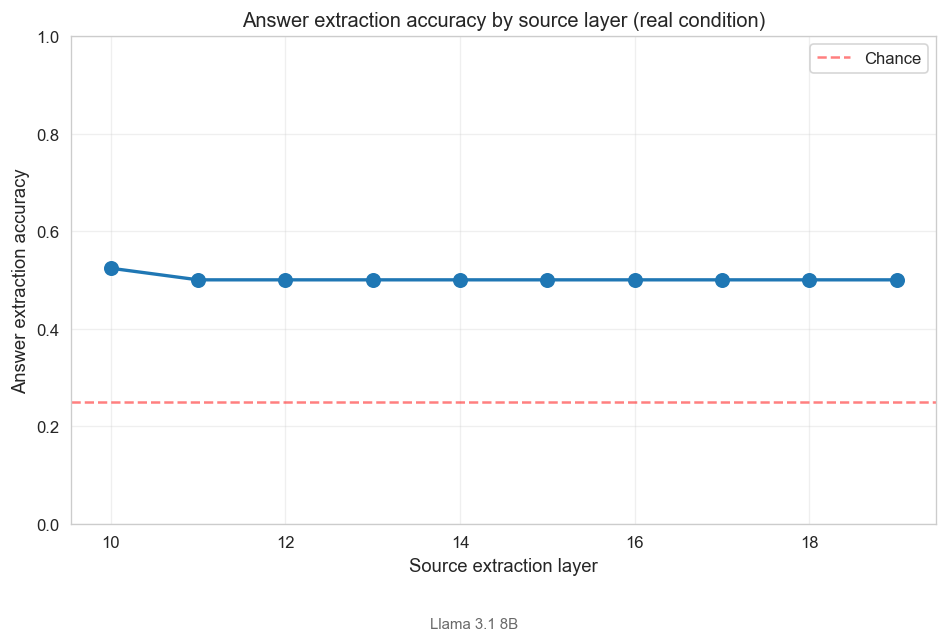


Persona probe accuracy by layer (real condition):


,accuracy,n
source_layer,,
10,0.667,21
11,0.667,18
12,0.667,18
13,0.667,18
14,0.667,18
15,0.667,18
16,0.667,18
17,0.667,18
18,0.667,18


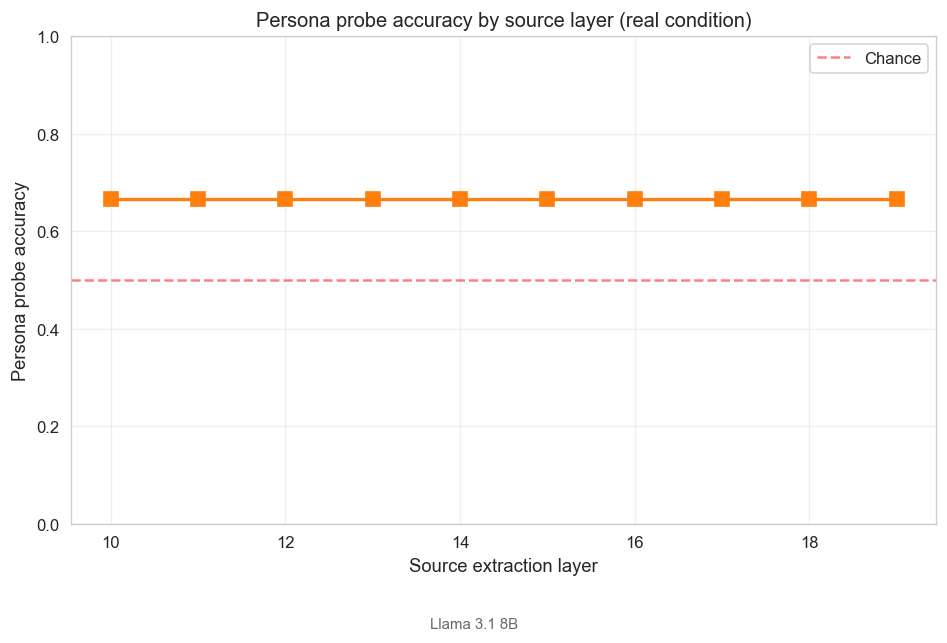

In [8]:
# Answer extraction accuracy by source layer (real condition only)
ae_real = ae[ae["condition"] == "real"].copy()

if ae_real["source_layer"].nunique() > 1:
    layer_acc = ae_real.groupby("source_layer")["correct"].agg(["mean", "count"])
    layer_acc.columns = ["accuracy", "n"]
    print("Answer extraction accuracy by layer (real condition):")
    display(layer_acc.round(3))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(layer_acc.index, layer_acc["accuracy"], "o-", linewidth=2, markersize=8)
    ax.axhline(0.25, color="red", linestyle="--", alpha=0.5, label="Chance")
    ax.set_xlabel("Source extraction layer")
    ax.set_ylabel("Answer extraction accuracy")
    ax.set_title("Answer extraction accuracy by source layer (real condition)")
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Persona probe accuracy by layer
    pp_real = pp[pp["condition"] == "real"].copy()
    if pp_real["source_layer"].nunique() > 1:
        pp_layer = pp_real.groupby("source_layer")["correct"].agg(["mean", "count"])
        pp_layer.columns = ["accuracy", "n"]
        print("\nPersona probe accuracy by layer (real condition):")
        display(pp_layer.round(3))

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(pp_layer.index, pp_layer["accuracy"], "s-", linewidth=2, markersize=8, color="C1")
        ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Chance")
        ax.set_xlabel("Source extraction layer")
        ax.set_ylabel("Persona probe accuracy")
        ax.set_title("Persona probe accuracy by source layer (real condition)")
        ax.legend()
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("Only one source layer — skipping layer analysis.")

## 9. Condition Comparison (Real vs Baseline vs Shuffled)

The key experimental question: does the **real** condition outperform **text_only_baseline** and **shuffled**?

Accuracy by template x condition:


accuracy    n
template_name     condition                        
answer_extraction real                0.502732  183
                  shuffled                 0.5   48
                  text_only_baseline  0.531915   47
persona_probe     real                0.666667  183
                  shuffled            0.571429   42
                  text_only_baseline  0.673469   49
self_recognition  real                 0.32967  182
                  shuffled            0.333333   48
                  text_only_baseline  0.255319   47


Accuracy pivot (template x condition):


condition,real,shuffled,text_only_baseline
template_name,,,
answer_extraction,0.502732,0.5,0.531915
persona_probe,0.666667,0.571429,0.673469
self_recognition,0.32967,0.333333,0.255319


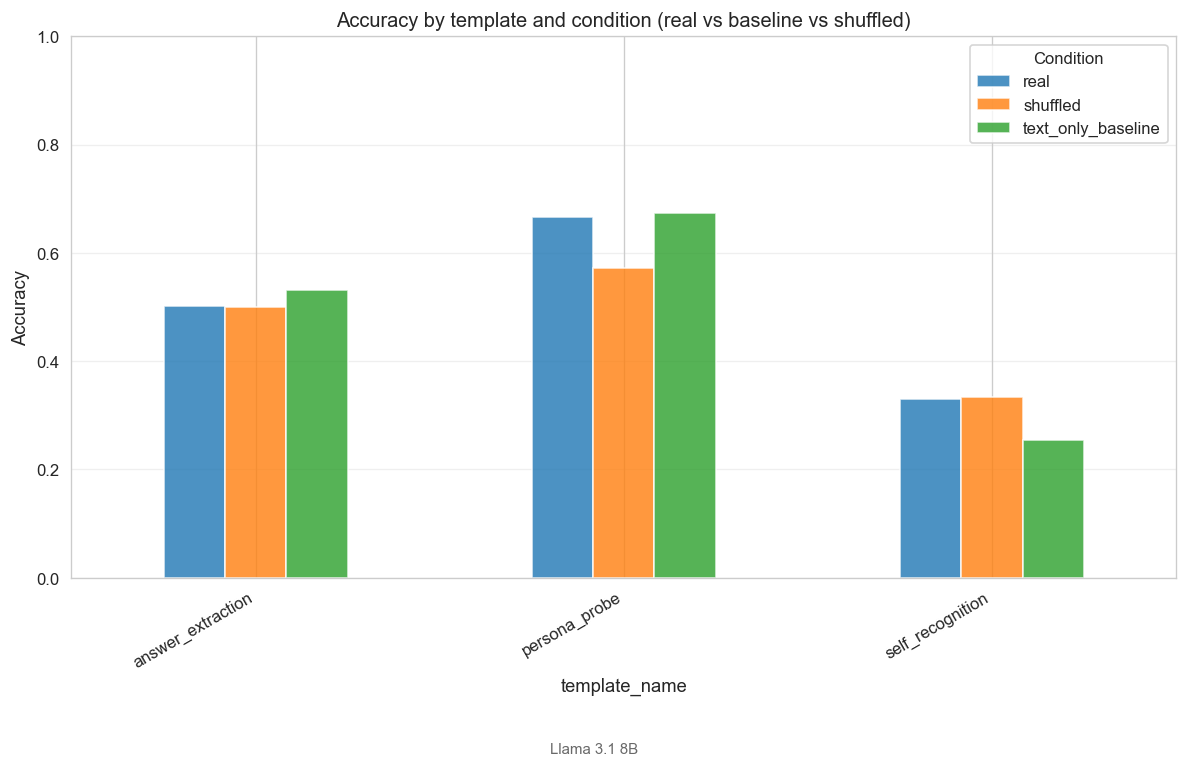

In [9]:
# Aggregate accuracy across all constrained templates
constrained_templates = ["answer_extraction", "persona_probe", "self_recognition", "agreement_probe"]
ct = df[df["template_name"].isin(constrained_templates)].copy()

def compute_correct(row):
    if not row["parse_success"]:
        return np.nan
    tmpl = row["template_name"]
    ans = (row["parsed_answer"] or "").lower()
    if tmpl == "answer_extraction":
        if row["source_direct_answer"]:
            return ans[:1].upper() == row["source_direct_answer"]
        return np.nan
    elif tmpl == "persona_probe":
        expected = "conservative" if "conservative" in row["source_persona"] else "progressive"
        return ans == expected
    elif tmpl == "self_recognition":
        is_self = row["source_persona"] == row["evaluator_persona"]
        expected = "self" if is_self else "other"
        return ans == expected
    return np.nan

ct["correct"] = ct.apply(compute_correct, axis=1)
ct_valid = ct[ct["correct"].notna()].copy()

# Summary: accuracy by template x condition
summary = ct_valid.groupby(["template_name", "condition"])["correct"].agg(["mean", "count"])
summary.columns = ["accuracy", "n"]
print("Accuracy by template x condition:")
display(summary.round(3))

# Pivot table (text-friendly)
pivot = ct_valid.groupby(["template_name", "condition"])["correct"].mean().unstack()
print("\nAccuracy pivot (template x condition):")
display(pivot.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, alpha=0.8, edgecolor="white")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by template and condition (real vs baseline vs shuffled)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Condition")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 10. Source x Evaluator Matrix

Heatmaps showing accuracy for self-read (same persona) vs cross-read (different persona) pairs.

Answer extraction accuracy: evaluator x source (real condition):


source_persona,persona_conservative
evaluator_persona,
neutral_evaluator,0.34
persona_conservative,0.98
persona_progressive,0.18


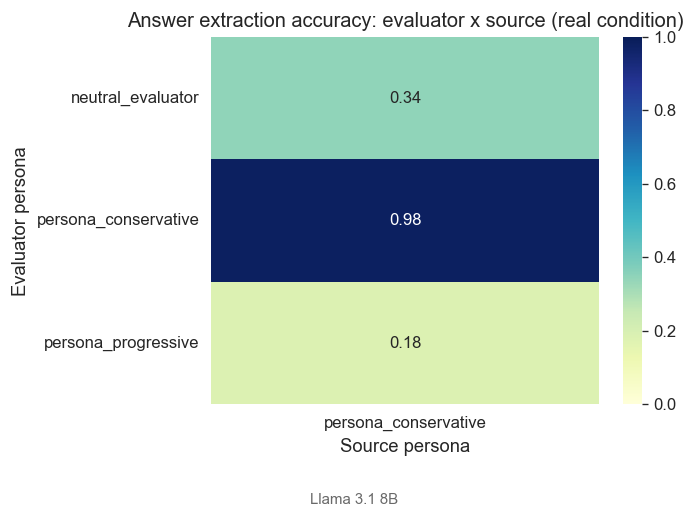


Persona probe accuracy: evaluator x source (real condition):


source_persona,persona_conservative
evaluator_persona,
neutral_evaluator,1.0
persona_conservative,1.0
persona_progressive,0.0


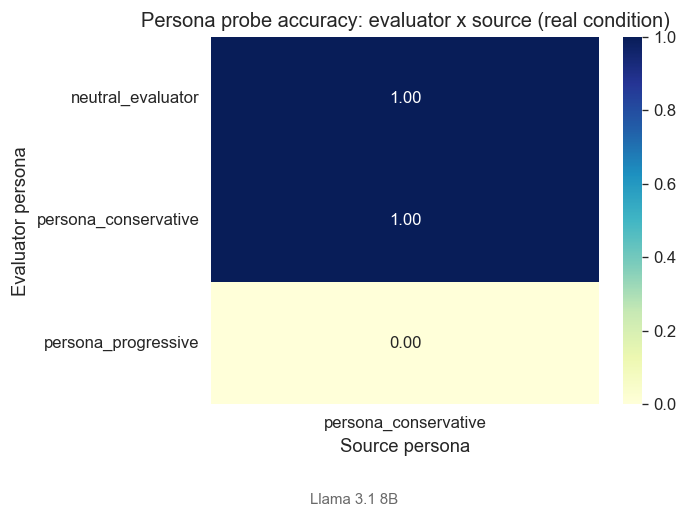

In [10]:
# Answer extraction: heatmap of accuracy by source x evaluator (real condition)
ae_real_valid = ae[(ae["condition"] == "real") & ae["correct"].notna()].copy()

if not ae_real_valid.empty:
    pivot = ae_real_valid.pivot_table(
        values="correct", index="evaluator_persona", columns="source_persona", aggfunc="mean"
    )
    print("Answer extraction accuracy: evaluator x source (real condition):")
    display(pivot.round(2))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
    ax.set_title("Answer extraction accuracy: evaluator x source (real condition)")
    ax.set_ylabel("Evaluator persona")
    ax.set_xlabel("Source persona")
    plt.tight_layout()
    plt.show()

# Persona probe: same heatmap
pp_real_valid = pp[(pp["condition"] == "real") & pp["correct"].notna()].copy()
if not pp_real_valid.empty:
    pivot = pp_real_valid.pivot_table(
        values="correct", index="evaluator_persona", columns="source_persona", aggfunc="mean"
    )
    print("\nPersona probe accuracy: evaluator x source (real condition):")
    display(pivot.round(2))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
    ax.set_title("Persona probe accuracy: evaluator x source (real condition)")
    ax.set_ylabel("Evaluator persona")
    ax.set_xlabel("Source persona")
    plt.tight_layout()
    plt.show()

## 11. Qualitative Examples

Sample generated interpretations from open_summary and belief_probe templates.

In [11]:
for tmpl in ["open_summary", "belief_probe"]:
    sub = df[(df["template_name"] == tmpl) & (df["condition"] == "real")].copy()
    if sub.empty:
        print(f"No {tmpl} records.")
        continue

    print(f"\n{'='*60}")
    print(f"  {tmpl.upper()} — sample interpretations (real condition)")
    print(f"{'='*60}")

    # Show one example per (source_persona, evaluator_persona) at a representative layer
    mid_layer = sorted(sub["source_layer"].unique())[len(sub["source_layer"].unique()) // 2]
    examples = sub[sub["source_layer"] == mid_layer].drop_duplicates(
        subset=["source_persona", "evaluator_persona"], keep="first"
    )
    for _, row in examples.iterrows():
        print(f"\n  Source: {row['source_persona']}  |  Evaluator: {row['evaluator_persona']}  |  Layer: {row['source_layer']}")
        print(f"  Question: {row['question_id']}  |  Source answer: {row['source_direct_answer']}")
        text = row["generated_text"][:500]
        print(f"  Response: {text}")
        print(f"  ---")


  OPEN_SUMMARY — sample interpretations (real condition)

  Source: persona_conservative  |  Evaluator: persona_conservative  |  Layer: 15
  Question: pol_186  |  Source answer: B
  Response: Representation is a fundamental aspect of a healthy democracy, and I believe it's essential to ensure that our system accurately reflects the will of the people. However, I also believe that representation should be grounded in tradition and the principles of federalism.

In my view, representation should be based on geographic districts, with elected officials accountable to their local communities. This approach promotes a sense of local ownership and responsibility, allowing citizens to hold 
  ---

  Source: persona_conservative  |  Evaluator: persona_progressive  |  Layer: 15
  Question: pol_186  |  Source answer: B
  Response: Representation is a crucial aspect of a healthy democracy, and I believe it's essential to ensure that all voices are heard and represented in the decision-making pro

## 12. Key Findings

In [12]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Answer extraction
for cond in ["real", "text_only_baseline", "shuffled"]:
    sub = ae[ae["condition"] == cond]
    if not sub.empty:
        acc = sub["correct"].mean()
        print(f"\n  Answer extraction [{cond}]: {acc:.1%}  (n={len(sub)}, chance=25%)")

# Persona probe
for cond in ["real", "text_only_baseline", "shuffled"]:
    sub = pp[pp["condition"] == cond]
    if not sub.empty:
        acc = sub["correct"].mean()
        print(f"  Persona probe [{cond}]: {acc:.1%}  (n={len(sub)}, chance=50%)")

# Self-recognition
for cond in ["real", "text_only_baseline", "shuffled"]:
    sub = sr[sr["condition"] == cond]
    if not sub.empty:
        acc = sub["correct"].mean()
        print(f"  Self-recognition [{cond}]: {acc:.1%}  (n={len(sub)}, chance=50%)")

# Real vs baseline delta
print("\n  --- Real vs Baseline delta ---")
for tmpl, ds in [("answer_extraction", ae), ("persona_probe", pp), ("self_recognition", sr)]:
    real_sub = ds[ds["condition"] == "real"]
    base_sub = ds[ds["condition"] == "text_only_baseline"]
    shuf_sub = ds[ds["condition"] == "shuffled"]
    real_acc = real_sub["correct"].mean() if len(real_sub) > 0 else float("nan")
    base_acc = base_sub["correct"].mean() if len(base_sub) > 0 else float("nan")
    shuf_acc = shuf_sub["correct"].mean() if len(shuf_sub) > 0 else float("nan")
    print(f"  {tmpl}: real={real_acc:.1%} - baseline={base_acc:.1%} = {real_acc - base_acc:+.1%}  |  real - shuffled = {real_acc - shuf_acc:+.1%}")

print("\n" + "=" * 60)

KEY FINDINGS

  Answer extraction [real]: 50.3%  (n=183, chance=25%)

  Answer extraction [text_only_baseline]: 53.2%  (n=47, chance=25%)

  Answer extraction [shuffled]: 50.0%  (n=48, chance=25%)
  Persona probe [real]: 66.7%  (n=183, chance=50%)
  Persona probe [text_only_baseline]: 67.3%  (n=49, chance=50%)
  Persona probe [shuffled]: 57.1%  (n=42, chance=50%)
  Self-recognition [real]: 33.0%  (n=182, chance=50%)
  Self-recognition [text_only_baseline]: 25.5%  (n=47, chance=50%)
  Self-recognition [shuffled]: 33.3%  (n=48, chance=50%)

  --- Real vs Baseline delta ---
  answer_extraction: real=50.3% - baseline=53.2% = -2.9%  |  real - shuffled = +0.3%
  persona_probe: real=66.7% - baseline=67.3% = -0.7%  |  real - shuffled = +9.5%
  self_recognition: real=33.0% - baseline=25.5% = +7.4%  |  real - shuffled = -0.4%

